In [2]:
# =============================================================================
# 🧹 NETTOYAGE SYSTÈME (SSH) - EXÉCUTER EN PREMIER!
# =============================================================================

import os, gc, shutil, glob

def quick_cleanup():
    """Nettoyage rapide avant exécution."""
    print("🧹 NETTOYAGE...")
    gc.collect()
    
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem = torch.cuda.memory_allocated() / 1e9
            print(f"✅ CUDA: {mem:.2f} GB alloué")
    except: pass
    
    for pattern in ['**/__pycache__', '**/.ipynb_checkpoints']:
        for p in glob.glob(pattern, recursive=True):
            try: shutil.rmtree(p)
            except: pass
    
    total, used, free = shutil.disk_usage('/')
    print(f"💾 Espace: {free/1e9:.1f} GB libre")
    print("✅ Prêt!")

quick_cleanup()

🧹 NETTOYAGE...
✅ CUDA: 0.00 GB alloué
✅ CUDA: 0.00 GB alloué
💾 Espace: 2.9 GB libre
✅ Prêt!
💾 Espace: 2.9 GB libre
✅ Prêt!


In [3]:
# =============================================================================
# 📦 IMPORTS & CONFIGURATION
# =============================================================================
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')
print(f'🔢 PyTorch version: {torch.__version__}')

🖥️ Device: cuda
🔢 PyTorch version: 2.8.0+cu128


## 📥 1. Chargement des Données

In [4]:
# =============================================================================
# 📂 PATHS CONFIGURATION - CORRIGÉS pour fichiers existants
# =============================================================================
DATA_DIR = './data'
EMB_DIR = os.path.join(DATA_DIR, 'embeddings')

# File paths - FICHIERS RÉELLEMENT EXISTANTS
paths = {
    # Embeddings CamemBERT (768d ou 2304d multi-layer)
    'train_embeddings': os.path.join(EMB_DIR, 'X_train_text_embeddings.npy'),
    'kaggle_embeddings': os.path.join(EMB_DIR, 'X_kaggle_text_embeddings.npy'),
    # Ou multi-layer (meilleur)
    'train_embeddings_ml': os.path.join(EMB_DIR, 'X_train_multilayer_embeddings.npy'),
    'kaggle_embeddings_ml': os.path.join(EMB_DIR, 'X_kaggle_multilayer_embeddings.npy'),
    # Features structurées (CSV de feature_engineering.ipynb)
    'train_features': os.path.join(DATA_DIR, 'train_features.csv'),
    'kaggle_features': os.path.join(DATA_DIR, 'test_features.csv'),
    # Labels
    'y_train': os.path.join(DATA_DIR, 'y_train.npy'),
}

# Check files exist
for name, path in paths.items():
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path} - MANQUANT")

❌ train_embeddings: ./data/embeddings/X_train_text_embeddings.npy - MANQUANT
❌ kaggle_embeddings: ./data/embeddings/X_kaggle_text_embeddings.npy - MANQUANT
✅ train_embeddings_ml: ./data/embeddings/X_train_multilayer_embeddings.npy
✅ kaggle_embeddings_ml: ./data/embeddings/X_kaggle_multilayer_embeddings.npy
✅ train_features: ./data/train_features.csv
✅ kaggle_features: ./data/test_features.csv
✅ y_train: ./data/y_train.npy


In [5]:
# =============================================================================
# 📊 LOAD DATA - Utilise les fichiers réels
# =============================================================================
def clean_array(arr):
    """Clean NaN/inf values and convert to float32."""
    arr = np.asarray(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    return arr.astype(np.float32)

# Load embeddings (utiliser multi-layer si disponible, sinon standard)
USE_MULTILAYER = os.path.exists(paths['train_embeddings_ml'])
if USE_MULTILAYER:
    X_train_emb = clean_array(np.load(paths['train_embeddings_ml']))
    X_kaggle_emb = clean_array(np.load(paths['kaggle_embeddings_ml']))
    print(f"📊 Using MULTILAYER embeddings (2304d)")
else:
    X_train_emb = clean_array(np.load(paths['train_embeddings']))
    X_kaggle_emb = clean_array(np.load(paths['kaggle_embeddings']))
    print(f"📊 Using standard embeddings (768d)")

# Load structured features from CSV (feature_engineering.ipynb output)
train_df = pd.read_csv(paths['train_features'])
kaggle_df = pd.read_csv(paths['kaggle_features'])

# ⭐ Features numériques les plus importantes (basées sur LightGBM feature importance)
# Ordonnées par importance décroissante selon feature_engineering.ipynb
TOP_FEATURES = [
    # TOP 6 features (importance > 500)
    'user_description_length',   # importance=736 ⭐
    'tweets_per_favourites',     # importance=699 ⭐
    'user_favourites_count',     # importance=646 ⭐
    'user_statuses_count',       # importance=639 ⭐
    'user_listed_count',         # importance=607 ⭐
    'listed_per_status',         # importance=553 ⭐
    # Log transforms (haute corrélation)
    'log_user_listed',           # corr=0.606 ⭐
    'log_user_statuses',         # corr=0.439
    'log_user_favourites',
    # Engagement features
    'total_engagement', 'log_total_engagement',
    'retweet_count', 'favorite_count', 'reply_count', 'quote_count',
    'log_retweet_count', 'log_favorite_count',
    # Binary user features (très discriminantes)
    'user_has_url',              # Observer=16%, Influencer=56%
    'user_has_banner',           # Observer=73%, Influencer=92%
    'user_has_location',         # Observer=58%, Influencer=75%
    'user_has_long_desc',
    'user_default_profile', 'user_default_profile_image',
    # Source device (très discriminant)
    'is_iphone', 'is_android', 'is_web', 'is_tweetdeck', 'is_bot_source',
    # Text features
    'tweet_length', 'word_count', 'uppercase_ratio',
    'hashtag_count', 'is_hashtag_heavy',
    'mention_count', 'is_mention_heavy',
    'emoji_count', 'is_emoji_heavy',
    'exclamation_count', 'question_count', 'has_multiple_exclamations',
    'url_count', 'has_url',
    # Content detection
    'is_reply', 'is_in_reply', 'is_reply_to_someone',
    'has_rt_qt', 'is_quote_status', 'has_quoted_status',
    'has_call_to_action', 'has_self_promotion', 'has_media_reference',
    # Entities
    'entities_hashtags', 'entities_urls', 'entities_mentions', 'entities_symbols',
    # Other
    'first_person_count', 'is_long_tweet', 'is_short_tweet'
]

# Filter to features that exist
available_features = [f for f in TOP_FEATURES if f in train_df.columns]
print(f"📊 Using {len(available_features)} structured features")

# Extract and clean features
X_train_feat = clean_array(train_df[available_features].fillna(0).values)
X_kaggle_feat = clean_array(kaggle_df[available_features].fillna(0).values)

# Normalize features
from sklearn.preprocessing import StandardScaler
feat_scaler = StandardScaler()
X_train_feat = feat_scaler.fit_transform(X_train_feat)
X_kaggle_feat = feat_scaler.transform(X_kaggle_feat)

# Load labels
y_full = np.load(paths['y_train'])
le = LabelEncoder()
y_full = le.fit_transform(y_full)

print(f"\n📊 Data Shapes:")
print(f"   Embeddings (train): {X_train_emb.shape}")
print(f"   Structured features (train): {X_train_feat.shape}")
print(f"   Labels: {y_full.shape}, Classes: {np.unique(y_full)}")
print(f"   Class distribution: {np.bincount(y_full)}")

📊 Using MULTILAYER embeddings (2304d)
📊 Using 58 structured features

📊 Data Shapes:
   Embeddings (train): (154914, 6144)
   Structured features (train): (154914, 58)
   Labels: (154914,), Classes: [0 1]
   Class distribution: [82674 72240]
📊 Using 58 structured features

📊 Data Shapes:
   Embeddings (train): (154914, 6144)
   Structured features (train): (154914, 58)
   Labels: (154914,), Classes: [0 1]
   Class distribution: [82674 72240]


## 🔧 2. Feature Engineering Avancé

Inspiré de Lab6 - Création de features combinées et interactions.

In [6]:
# =============================================================================
# 🔧 COMBINE EMBEDDINGS + FEATURES
# =============================================================================

# Combine: embeddings + structured features
X_train_combined = np.hstack([X_train_emb, X_train_feat])
X_kaggle_combined = np.hstack([X_kaggle_emb, X_kaggle_feat])

print(f"📊 Combined features:")
print(f"   Train: {X_train_combined.shape}")
print(f"   Kaggle: {X_kaggle_combined.shape}")

# Calculate dimensions for the neural network
EMB_DIM = X_train_emb.shape[1]
FEAT_DIM = X_train_feat.shape[1]
TOTAL_DIM = X_train_combined.shape[1]

print(f"\n🔢 Dimensions:")
print(f"   Embedding dim: {EMB_DIM}")
print(f"   Feature dim: {FEAT_DIM}")
print(f"   Total dim: {TOTAL_DIM}")

📊 Combined features:
   Train: (154914, 6202)
   Kaggle: (103380, 6202)

🔢 Dimensions:
   Embedding dim: 6144
   Feature dim: 58
   Total dim: 6202


In [7]:
# =============================================================================
# 📊 TRAIN/VAL SPLIT
# =============================================================================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_combined, y_full, 
    test_size=0.15, 
    random_state=SEED, 
    stratify=y_full
)

# Also split embeddings and features separately for multi-branch model
X_train_emb_split, X_val_emb_split = train_test_split(
    X_train_emb, test_size=0.15, random_state=SEED, stratify=y_full
)
X_train_feat_split, X_val_feat_split = train_test_split(
    X_train_feat, test_size=0.15, random_state=SEED, stratify=y_full
)

print(f"📊 Train/Val split:")
print(f"   Train: {X_train.shape}, Labels: {np.bincount(y_train)}")
print(f"   Val: {X_val.shape}, Labels: {np.bincount(y_val)}")

📊 Train/Val split:
   Train: (131676, 6202), Labels: [70272 61404]
   Val: (23238, 6202), Labels: [12402 10836]


## 🧠 3. Neural Network Architecture (Lab4 + Lab5 inspired)

Multi-branch architecture avec:
- Dropout régularisation (Lab4)
- Batch Normalization
- Residual connections (Lab5 Transformer concept)
- Multi-Sample Dropout (recommandé dans TODO.md)

In [8]:
# =============================================================================
# 🧠 SIMPLIFIED NEURAL NETWORK (uses combined embeddings)
# =============================================================================

class MultiSampleDropout(nn.Module):
    """Multi-Sample Dropout - averages multiple dropout masks."""
    def __init__(self, dropout_rates=[0.1, 0.2, 0.3, 0.4, 0.5]):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(p) for p in dropout_rates])
    
    def forward(self, x):
        if self.training:
            return torch.mean(torch.stack([d(x) for d in self.dropouts]), dim=0)
        return x


class InfluencerClassifierSimple(nn.Module):
    """
    Simplified Classifier for combined embeddings + features.
    
    Architecture:
    - Single branch for combined input (embeddings + structured features)
    - Deep MLP with BatchNorm and Dropout
    - Multi-Sample Dropout for regularization
    """
    
    def __init__(self, input_dim, hidden_dim=512, n_classes=2, dropout=0.3):
        super().__init__()
        
        # Main network
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            # Layer 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            # Layer 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(inplace=True),
        )
        
        # Multi-Sample Dropout
        self.ms_dropout = MultiSampleDropout([0.1, 0.2, 0.3])
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim // 4, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, n_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        """He initialization for ReLU networks."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.network(x)
        x = self.ms_dropout(x)
        return self.classifier(x)


# Test the model
model = InfluencerClassifierSimple(
    input_dim=TOTAL_DIM,  # 6202 = 6144 embeddings + 58 features
    hidden_dim=512,
    n_classes=2,
    dropout=0.3
)
print(f"📐 Model architecture:")
print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")

📐 Model architecture:
InfluencerClassifierSimple(
  (network): Sequential(
    (0): Linear(in_features=6202, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (ms_dropout): MultiSampleDropout(
    (dropouts): ModuleList(
      (0): Dropout(p=0.1, inplace=False)
      (1): Dropout(p=0.2, inplace=False)
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU(i

## 🏋️ 4. Training Loop (Lab4 + Lab8 inspired)

Avec:
- AdamW optimizer avec weight decay (Lab8)
- Learning rate scheduling (OneCycleLR)
- Early stopping
- Gradient clipping

In [ ]:
# =============================================================================
# 📦 DATASET & DATALOADER (Optimisé GPU RTX 4000)
# =============================================================================

class SimpleDataset(Dataset):
    """Simple dataset for combined features."""
    def __init__(self, features, labels=None):
        self.features = torch.from_numpy(features).float()
        self.labels = None if labels is None else torch.from_numpy(labels).long()
    
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, idx):
        if self.labels is None:
            return self.features[idx]
        return self.features[idx], self.labels[idx]


# Create datasets - optimisé pour RTX 4000 Ada
batch_size = 512  # 🚀 Grand batch pour GPU (était 64)

train_dataset = SimpleDataset(X_train, y_train)
val_dataset = SimpleDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True)

print(f"📊 DataLoaders created (optimisé RTX 4000):")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

📊 DataLoaders created:
   Train batches: 2058
   Val batches: 364


In [10]:
# =============================================================================
# 🏋️ TRAINING UTILITIES (Simplified)
# =============================================================================

def train_epoch(model, loader, optimizer, criterion, scheduler, device, max_grad_norm=1.0):
    """Train for one epoch with gradient clipping."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in loader:
        features, labels = batch[0].to(device), batch[1].to(device)
        
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


def evaluate(model, loader, criterion, device):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            features, labels = batch[0].to(device), batch[1].to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, np.array(all_probs)


def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 Score
    axes[2].plot(history['train_f1'], label='Train')
    axes[2].plot(history['val_f1'], label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title('F1 Score Curve')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [11]:
# =============================================================================
# 🚀 TRAINING CONFIGURATION
# =============================================================================

# Hyperparameters
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 0.01
PATIENCE = 5

# Initialize model
model = InfluencerClassifierSimple(
    input_dim=TOTAL_DIM,
    hidden_dim=512,
    n_classes=2,
    dropout=0.3
).to(device)

# Loss function with class weights (handle imbalance)
class_counts = np.bincount(y_train)
class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * 2
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW optimizer
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = OneCycleLR(
    optimizer, 
    max_lr=LR,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos'
)

print(f"🚀 Training configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LR}")
print(f"   Weight decay: {WEIGHT_DECAY}")
print(f"   Class weights: {class_weights.cpu().numpy()}")

🚀 Training configuration:
   Epochs: 20
   Learning rate: 0.001
   Weight decay: 0.01
   Class weights: [0.9326529 1.067347 ]


In [12]:
# =============================================================================
# 🏃 RUN TRAINING
# =============================================================================

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

best_val_acc = 0
best_val_f1 = 0
patience_counter = 0
best_model_state = None

print("\n" + "="*70)
print("🏋️ TRAINING STARTED")
print("="*70)

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, device
    )
    
    # Evaluate
    val_loss, val_acc, val_f1, val_probs = evaluate(
        model, val_loader, criterion, device
    )
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    # Print progress
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"   ✅ New best model! Val F1: {val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break

print("\n" + "="*70)
print(f"🏆 Best model - Val Accuracy: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}")
print("="*70)

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)


🏋️ TRAINING STARTED
Epoch  1/20 | Train Loss: 1.0862 Acc: 0.7154 F1: 0.7145 | Val Loss: 0.4211 Acc: 0.8208 F1: 0.8183
   ✅ New best model! Val F1: 0.8183
Epoch  1/20 | Train Loss: 1.0862 Acc: 0.7154 F1: 0.7145 | Val Loss: 0.4211 Acc: 0.8208 F1: 0.8183
   ✅ New best model! Val F1: 0.8183
Epoch  2/20 | Train Loss: 0.4228 Acc: 0.8182 F1: 0.8171 | Val Loss: 0.3790 Acc: 0.8404 F1: 0.8398
   ✅ New best model! Val F1: 0.8398
Epoch  2/20 | Train Loss: 0.4228 Acc: 0.8182 F1: 0.8171 | Val Loss: 0.3790 Acc: 0.8404 F1: 0.8398
   ✅ New best model! Val F1: 0.8398
Epoch  3/20 | Train Loss: 0.3720 Acc: 0.8411 F1: 0.8401 | Val Loss: 0.3521 Acc: 0.8493 F1: 0.8477
   ✅ New best model! Val F1: 0.8477
Epoch  3/20 | Train Loss: 0.3720 Acc: 0.8411 F1: 0.8401 | Val Loss: 0.3521 Acc: 0.8493 F1: 0.8477
   ✅ New best model! Val F1: 0.8477
Epoch  4/20 | Train Loss: 0.3455 Acc: 0.8528 F1: 0.8518 | Val Loss: 0.3255 Acc: 0.8616 F1: 0.8605
   ✅ New best model! Val F1: 0.8605
Epoch  4/20 | Train Loss: 0.3455 Acc: 0.8

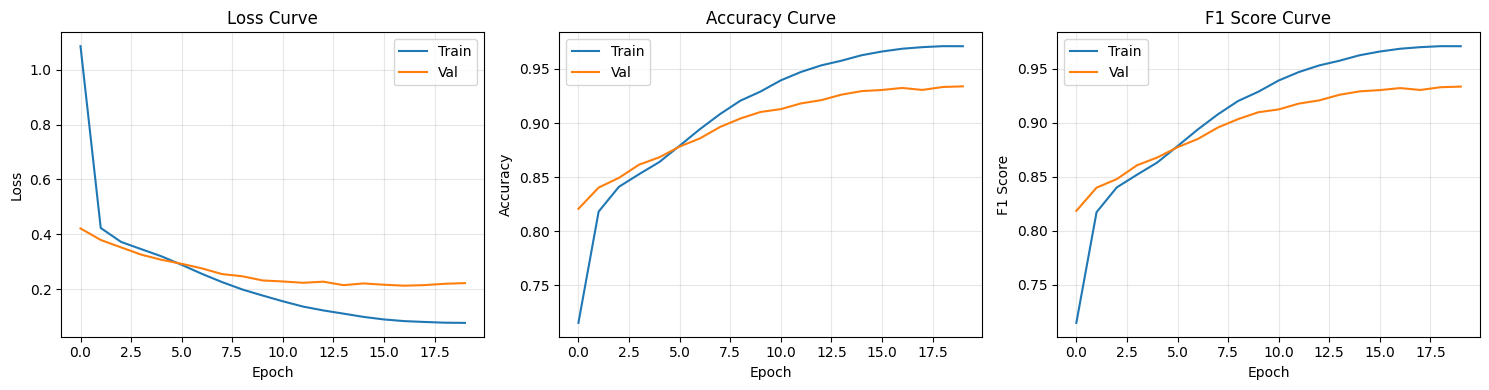

In [13]:
# Plot training history
plot_training_history(history)

## 🌳 5. Gradient Boosting Models (Ensemble Diversity)

In [ ]:
# =============================================================================
# 🌳 XGBOOST & LIGHTGBM (GPU + CPU optimisé) - i7-14700K + RTX 4000
# =============================================================================

# Configuration hardware
N_THREADS = 20  # i7-14700K: 20 cœurs physiques

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# XGBoost - GPU RTX 4000 Ada 🚀
print("\n🌳 Training XGBoost (GPU: RTX 4000 Ada)...")
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist',      # 🚀 GPU optimisé
    device='cuda',           # 🚀 RTX 4000
    max_bin=256,
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=True
)

xgb_preds = xgb_model.predict(X_val_scaled)
xgb_probs = xgb_model.predict_proba(X_val_scaled)
print(f"   XGBoost Val Accuracy: {accuracy_score(y_val, xgb_preds):.4f}")
print(f"   XGBoost Val F1: {f1_score(y_val, xgb_preds, average='macro'):.4f}")

# LightGBM - CPU multi-thread 🚀
print(f"\n🌳 Training LightGBM (CPU: {N_THREADS} threads)...")
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=N_THREADS,        # 🚀 Tous les cœurs
    verbose=-1
)

lgbm_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)]
)

lgbm_preds = lgbm_model.predict(X_val_scaled)
lgbm_probs = lgbm_model.predict_proba(X_val_scaled)
print(f"   LightGBM Val Accuracy: {accuracy_score(y_val, lgbm_preds):.4f}")
print(f"   LightGBM Val F1: {f1_score(y_val, lgbm_preds, average='macro'):.4f}")

## 🎲 6. Ensemble (Weighted Voting)

In [15]:
# =============================================================================
# 🎲 ENSEMBLE - WEIGHTED VOTING
# =============================================================================

# Get Neural Network predictions
_, nn_val_acc, nn_val_f1, nn_val_probs = evaluate(model, val_loader, criterion, device)

# Ensemble weights (based on validation F1)
weights = {
    'nn': nn_val_f1,
    'xgb': f1_score(y_val, xgb_preds, average='macro'),
    'lgbm': f1_score(y_val, lgbm_preds, average='macro')
}

# Normalize weights
total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}

print("\n🎲 Ensemble Weights:")
for name, w in weights.items():
    print(f"   {name}: {w:.4f}")

# Weighted average of probabilities
ensemble_probs = (
    weights['nn'] * nn_val_probs +
    weights['xgb'] * xgb_probs +
    weights['lgbm'] * lgbm_probs
)

ensemble_preds = np.argmax(ensemble_probs, axis=1)
ensemble_acc = accuracy_score(y_val, ensemble_preds)
ensemble_f1 = f1_score(y_val, ensemble_preds, average='macro')

print(f"\n🏆 Ensemble Results:")
print(f"   Accuracy: {ensemble_acc:.4f}")
print(f"   F1 Score: {ensemble_f1:.4f}")

# Compare all models
print("\n" + "="*50)
print("📊 MODEL COMPARISON")
print("="*50)
print(f"{'Model':<15} {'Accuracy':>10} {'F1 Score':>10}")
print("-"*35)
print(f"{'Neural Net':<15} {nn_val_acc:>10.4f} {nn_val_f1:>10.4f}")
print(f"{'XGBoost':<15} {accuracy_score(y_val, xgb_preds):>10.4f} {f1_score(y_val, xgb_preds, average='macro'):>10.4f}")
print(f"{'LightGBM':<15} {accuracy_score(y_val, lgbm_preds):>10.4f} {f1_score(y_val, lgbm_preds, average='macro'):>10.4f}")
print(f"{'Ensemble':<15} {ensemble_acc:>10.4f} {ensemble_f1:>10.4f}")
print("="*50)


🎲 Ensemble Weights:
   nn: 0.3510
   xgb: 0.3248
   lgbm: 0.3243

🏆 Ensemble Results:
   Accuracy: 0.9191
   F1 Score: 0.9185

📊 MODEL COMPARISON
Model             Accuracy   F1 Score
-----------------------------------
Neural Net          0.9339     0.9334
XGBoost             0.8648     0.8637
LightGBM            0.8635     0.8625
Ensemble            0.9191     0.9185


## 📝 7. Generate Kaggle Submission

In [16]:
# =============================================================================
# 📝 GENERATE KAGGLE SUBMISSION
# =============================================================================

# Scale Kaggle data for boosting models
X_kaggle_scaled = scaler.transform(X_kaggle_combined)

# Create Kaggle dataset for NN
kaggle_dataset = SimpleDataset(X_kaggle_combined, labels=None)
kaggle_loader = DataLoader(kaggle_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)

# Get predictions from all models
print("\n📝 Generating predictions...")

# Neural Network
model.eval()
nn_kaggle_probs = []
with torch.no_grad():
    for batch in kaggle_loader:
        features = batch.to(device)
        logits = model(features)
        probs = F.softmax(logits, dim=1)
        nn_kaggle_probs.extend(probs.cpu().numpy())
nn_kaggle_probs = np.array(nn_kaggle_probs)

# XGBoost & LightGBM
xgb_kaggle_probs = xgb_model.predict_proba(X_kaggle_scaled)
lgbm_kaggle_probs = lgbm_model.predict_proba(X_kaggle_scaled)

# Ensemble
ensemble_kaggle_probs = (
    weights['nn'] * nn_kaggle_probs +
    weights['xgb'] * xgb_kaggle_probs +
    weights['lgbm'] * lgbm_kaggle_probs
)
ensemble_kaggle_preds = np.argmax(ensemble_kaggle_probs, axis=1)

print(f"   Total predictions: {len(ensemble_kaggle_preds)}")
print(f"   Class distribution: {np.bincount(ensemble_kaggle_preds)}")


📝 Generating predictions...
   Total predictions: 103380
   Class distribution: [57720 45660]
   Total predictions: 103380
   Class distribution: [57720 45660]


In [17]:
# =============================================================================
# 💾 SAVE SUBMISSION
# =============================================================================

# Load test data for IDs
kaggle_df = pd.read_json('data/kaggle_test.jsonl', lines=True)
kaggle_df = pd.json_normalize(kaggle_df.to_dict(orient='records'))

# Get challenge IDs
ids = kaggle_df['challenge_id'].astype(int).values

# Create submission DataFrame
submission = pd.DataFrame({
    'ID': ids,
    'Prediction': ensemble_kaggle_preds
})

# Save
os.makedirs('submission', exist_ok=True)
submission_path = 'submission/submission_model_with_features.csv'
submission.to_csv(submission_path, index=False)

print(f"\n✅ Submission saved to: {submission_path}")
print(f"   Shape: {submission.shape}")
print(f"   Class distribution: {submission['Prediction'].value_counts().to_dict()}")
print("\n📊 Sample predictions:")
print(submission.head(10))


✅ Submission saved to: submission/submission_model_with_features.csv
   Shape: (103380, 2)
   Class distribution: {0: 57720, 1: 45660}

📊 Sample predictions:
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           1
4   9           0
5  10           1
6  13           0
7  14           0
8  15           1
9  19           0


## 📈 8. Résumé et Prochaines Étapes

### Ce notebook combine:
1. **Lab4 Techniques**: Dropout, Weight Decay, Gradient Clipping
2. **Lab5 Techniques**: Transfer Learning via CamemBERT embeddings
3. **Lab6 Techniques**: Feature Engineering, interaction features
4. **Lab8 Techniques**: AdamW optimizer, Learning Rate Scheduling

### Améliorations possibles:
- Fine-tuning CamemBERT end-to-end (si GPU disponible)
- Pseudo-labeling sur les prédictions confiantes
- Cross-validation pour des poids d'ensemble plus robustes
- Test-Time Augmentation (TTA)

In [18]:
# =============================================================================
# 💾 SAVE MODEL CHECKPOINT
# =============================================================================

os.makedirs('models', exist_ok=True)

# Save Neural Network
checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_dim': TOTAL_DIM,
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
    'weights': weights
}
torch.save(checkpoint, 'models/influencer_model_simple.pt')

# Save XGBoost & LightGBM
import joblib
joblib.dump(xgb_model, 'models/xgb_model.joblib')
joblib.dump(lgbm_model, 'models/lgbm_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print("✅ All models saved!")

✅ All models saved!
